In [1]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_parquet("green_tripdata_2021-01.parquet")

In [2]:
print("Shape:", data.shape)
print("\nData Types:")
print(data.dtypes)
print("\nSample Preview:")
data.head()

Shape: (76518, 20)

Data Types:
VendorID                          int64
lpep_pickup_datetime     datetime64[ns]
lpep_dropoff_datetime    datetime64[ns]
store_and_fwd_flag               object
RatecodeID                      float64
PULocationID                      int64
DOLocationID                      int64
passenger_count                 float64
trip_distance                   float64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
ehail_fee                       float64
improvement_surcharge           float64
total_amount                    float64
payment_type                    float64
trip_type                       float64
congestion_surcharge            float64
dtype: object

Sample Preview:


,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
0,2,2021-01-01 00:15:56,2021-01-01 00:19:52,N,1.0,43,151,1.0,1.01,5.5,0.5,0.5,0.00,0.0,NaN,0.3,6.80,2.0,1.0,0.00
1,2,2021-01-01 00:25:59,2021-01-01 00:34:44,N,1.0,166,239,1.0,2.53,10.0,0.5,0.5,2.81,0.0,NaN,0.3,16.86,1.0,1.0,2.75
2,2,2021-01-01 00:45:57,2021-01-01 00:51:55,N,1.0,41,42,1.0,1.12,6.0,0.5,0.5,1.00,0.0,NaN,0.3,8.30,1.0,1.0,0.00
3,2,2020-12-31 23:57:51,2021-01-01 00:04:56,N,1.0,168,75,1.0,1.99,8.0,0.5,0.5,0.00,0.0,NaN,0.3,9.30,2.0,1.0,0.00
4,2,2021-01-01 00:16:36,2021-01-01 00:16:40,N,2.0,265,265,3.0,0.00,-52.0,0.0,-0.5,0.00,0.0,NaN,-0.3,-52.80,3.0,1.0,0.00


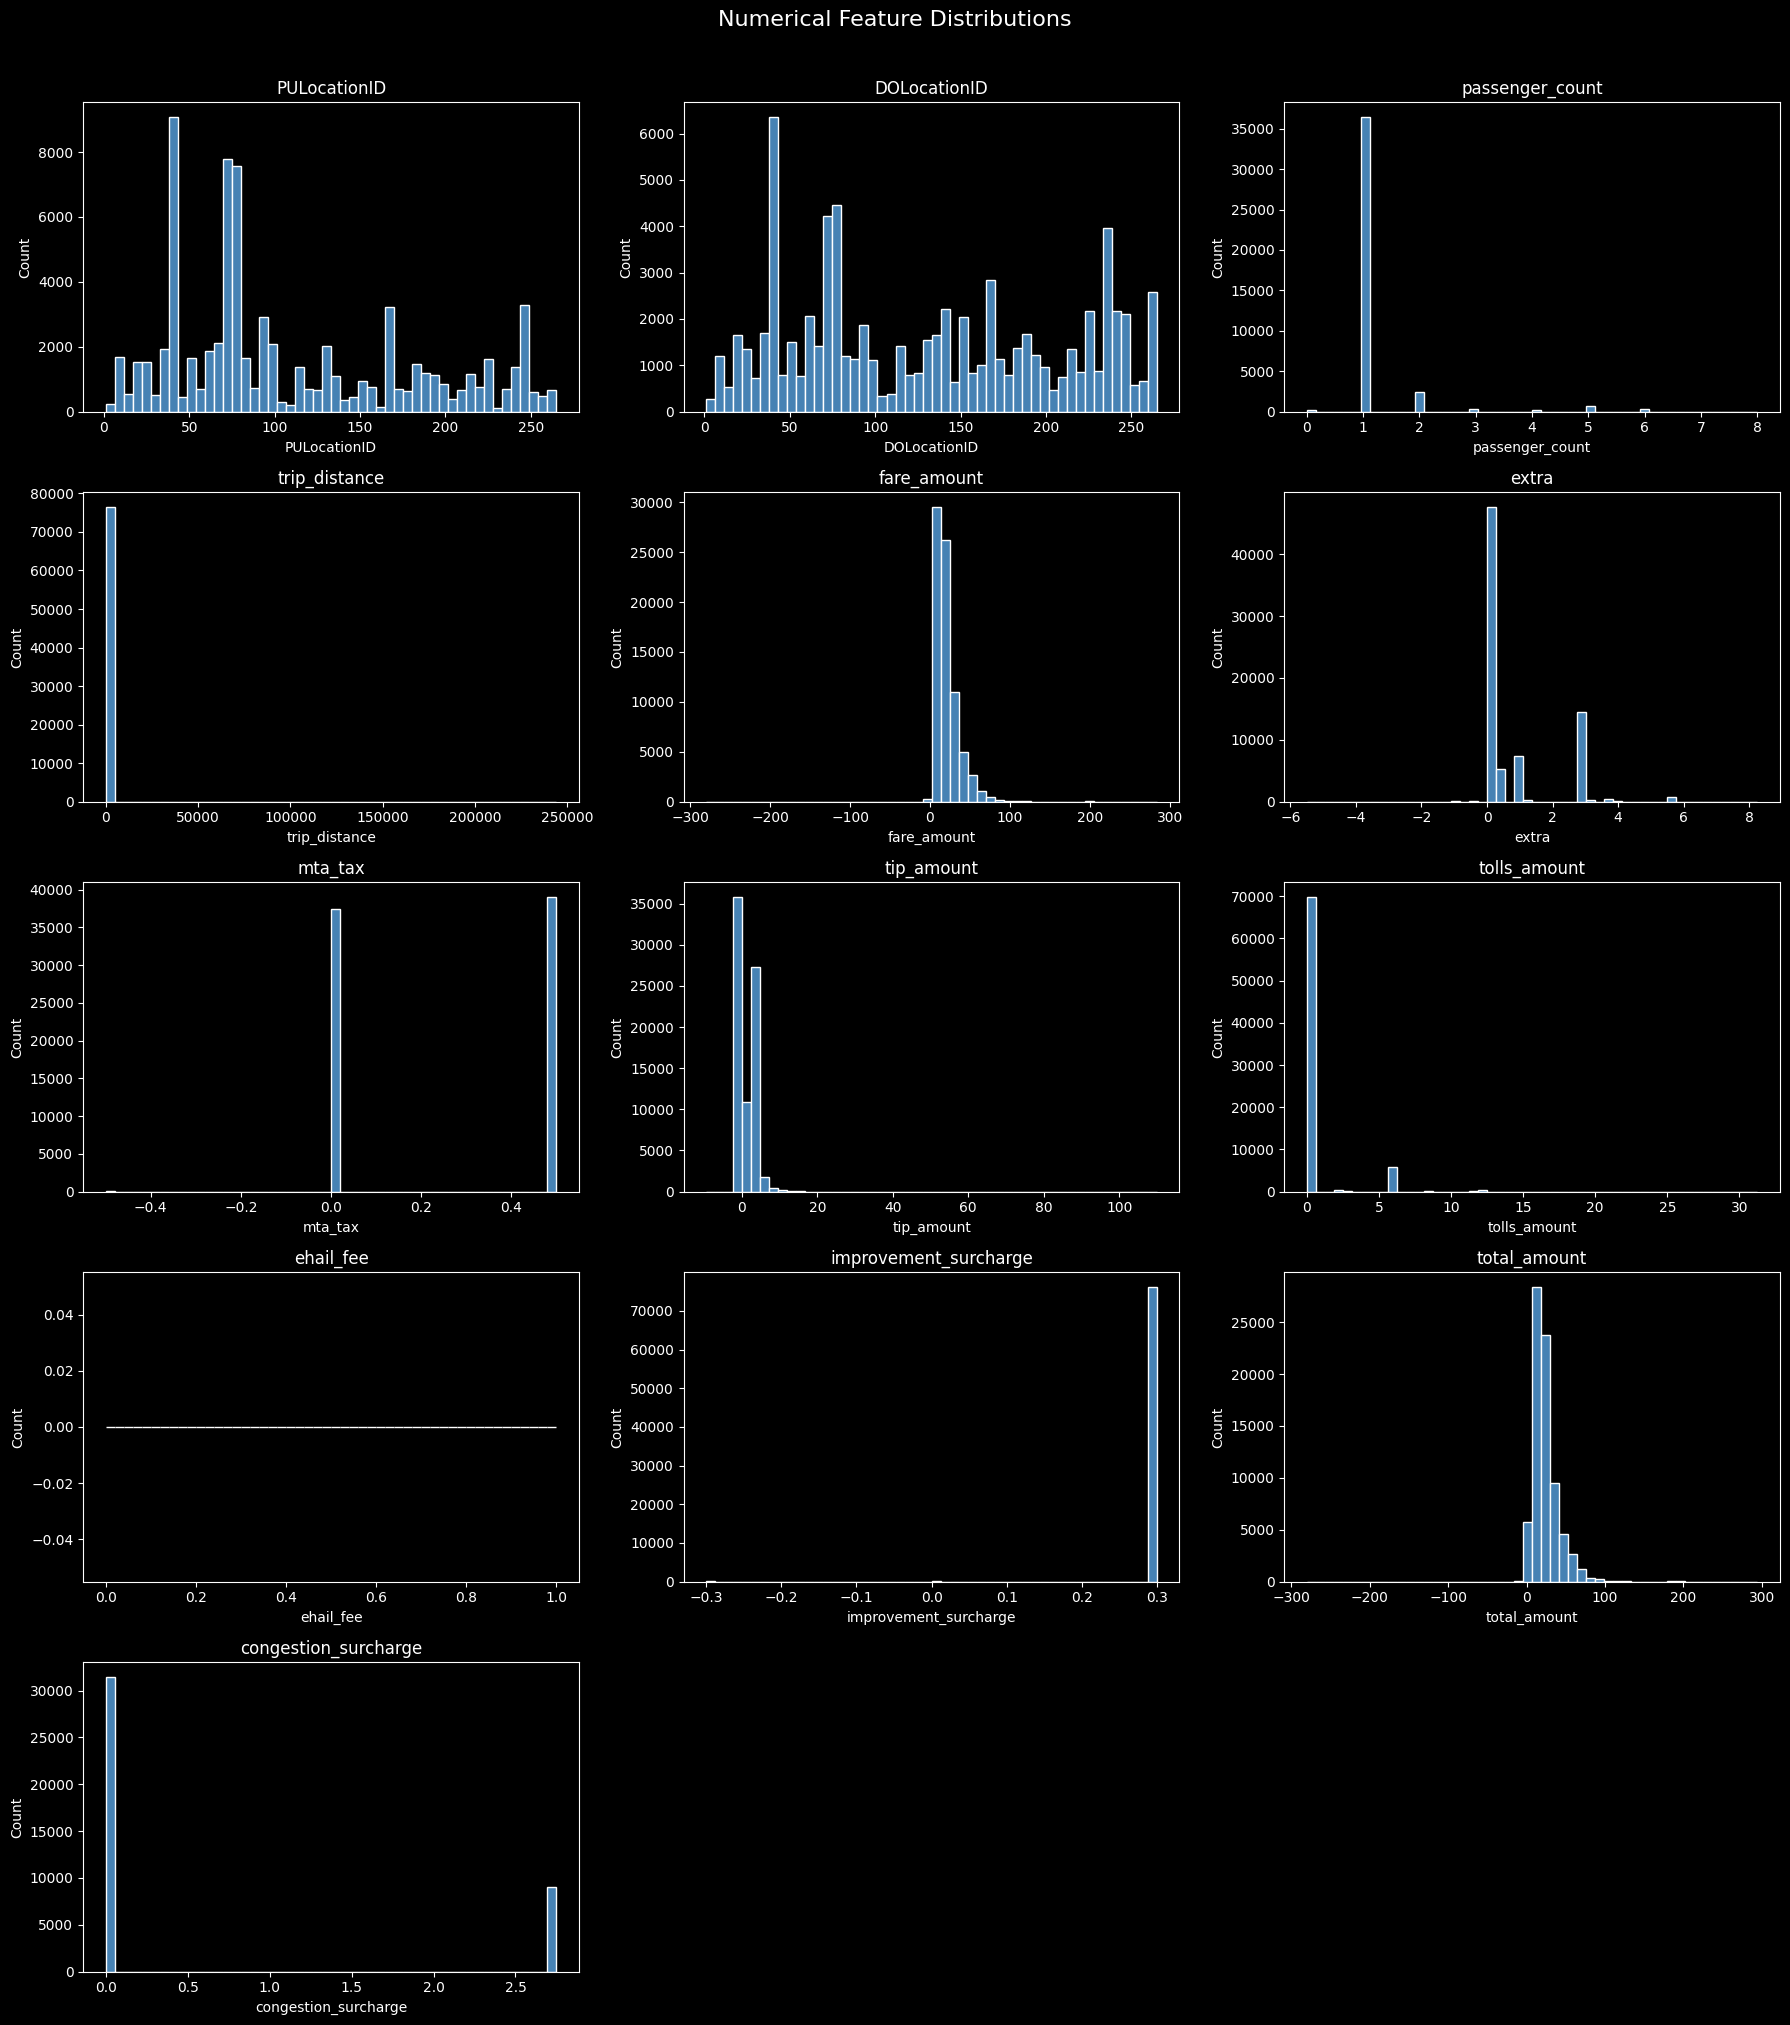

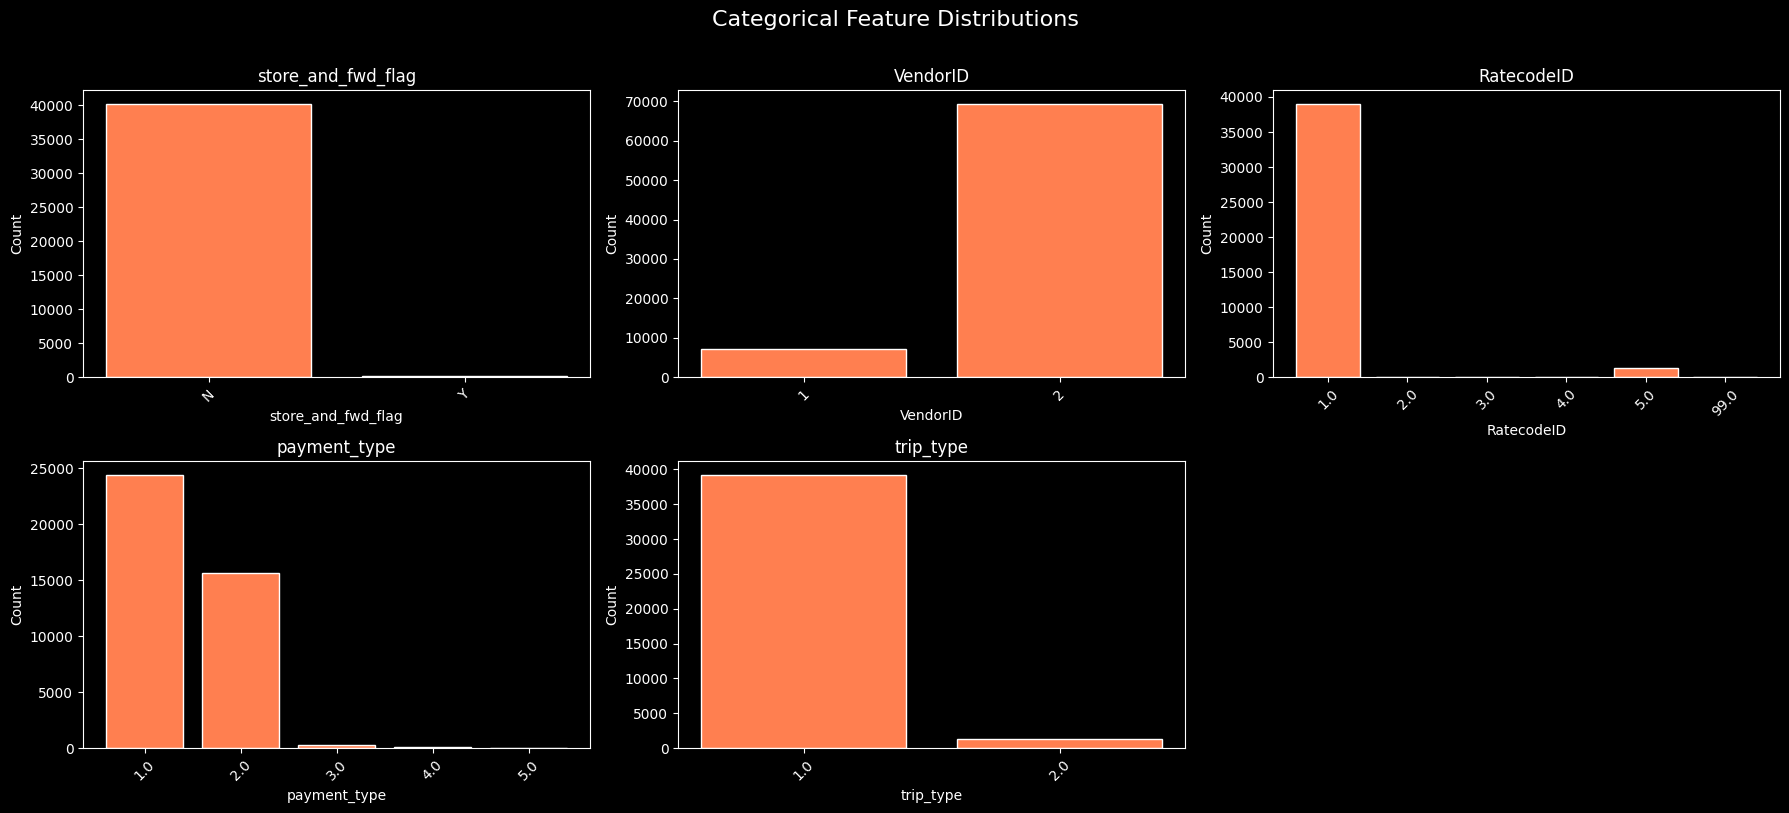

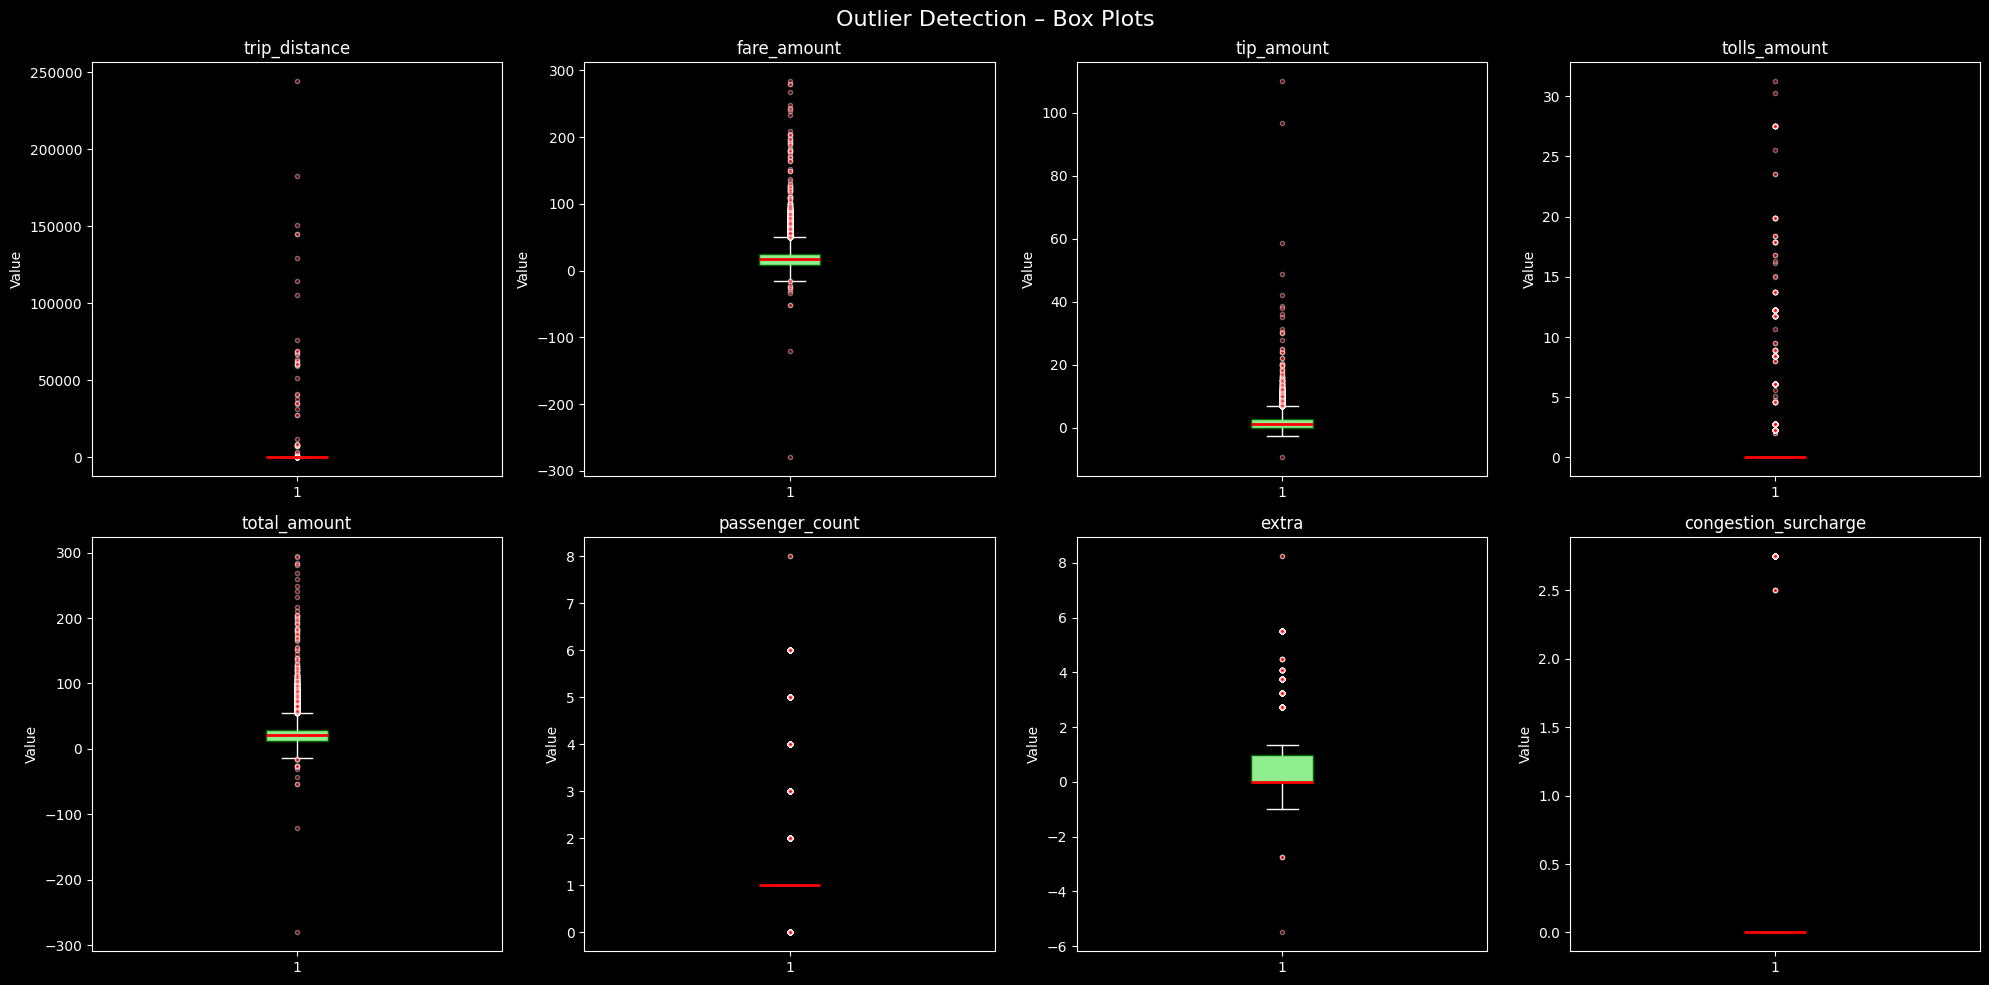

Outlier summary (IQR method):

  trip_distance             outliers:  6,773  (8.85%)
  fare_amount               outliers:  3,532  (4.62%)
  tip_amount                outliers:    933  (1.22%)
  tolls_amount              outliers:  6,698  (8.75%)
  total_amount              outliers:  3,862  (5.05%)
  passenger_count           outliers:  4,025  (9.95%)
  extra                     outliers: 15,938  (20.83%)
  congestion_surcharge      outliers:  9,034  (22.32%)


In [3]:
# Column groups
num_cols = data.select_dtypes(include='number').columns.tolist()
cat_cols = data.select_dtypes(include=['object', 'category']).columns.tolist()
# Numeric columns that are better shown as bar charts
id_like = ['VendorID', 'RatecodeID', 'payment_type', 'trip_type']
true_num = [c for c in num_cols if c not in id_like]

# 1. Histograms – numerical feature distributions
n_cols = 3
n_rows = -(-len(true_num) // n_cols)          # ceiling division
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()
for i, col in enumerate(true_num):
    axes[i].hist(data[col].dropna(), bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Numerical Feature Distributions', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

# 2. Bar charts – categorical / low-cardinality feature distributions
bar_cols = cat_cols + id_like
n_rows2 = -(-len(bar_cols) // n_cols)
fig2, axes2 = plt.subplots(n_rows2, n_cols, figsize=(18, n_rows2 * 4))
axes2 = axes2.flatten()
for i, col in enumerate(bar_cols):
    vc = data[col].value_counts().sort_index()
    axes2[i].bar(vc.index.astype(str), vc.values, color='coral', edgecolor='white')
    axes2[i].set_title(col)
    axes2[i].set_xlabel(col)
    axes2[i].set_ylabel('Count')
    axes2[i].tick_params(axis='x', rotation=45)
for j in range(i + 1, len(axes2)):
    axes2[j].set_visible(False)
plt.suptitle('Categorical Feature Distributions', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

# 3. Box plots – outlier identification
# Focus on the most meaningful numeric columns for outlier analysis
outlier_cols = ['trip_distance', 'fare_amount', 'tip_amount',
                'tolls_amount', 'total_amount', 'passenger_count',
                'extra', 'congestion_surcharge']
outlier_cols = [c for c in outlier_cols if c in data.columns]

fig3, axes3 = plt.subplots(2, 4, figsize=(20, 10))
axes3 = axes3.flatten()
for i, col in enumerate(outlier_cols):
    axes3[i].boxplot(data[col].dropna(), vert=True, patch_artist=True,
                     boxprops=dict(facecolor='lightgreen', color='darkgreen'),
                     medianprops=dict(color='red', linewidth=2),
                     flierprops=dict(marker='o', markerfacecolor='red',
                                     markersize=3, alpha=0.4))
    axes3[i].set_title(col)
    axes3[i].set_ylabel('Value')
for j in range(i + 1, len(axes3)):
    axes3[j].set_visible(False)
plt.suptitle('Outlier Detection – Box Plots', fontsize=16)
plt.tight_layout()
plt.show()

# IQR-based outlier summary
print("Outlier summary (IQR method):\n")
for col in outlier_cols:
    q1, q3 = data[col].quantile(0.25), data[col].quantile(0.75)
    iqr = q3 - q1
    n_out = ((data[col] < q1 - 1.5 * iqr) | (data[col] > q3 + 1.5 * iqr)).sum()
    pct = n_out / data[col].notna().sum() * 100
    print(f"  {col:<25} outliers: {n_out:>6,}  ({pct:.2f}%)")


In [4]:
#  DATA CLEANING

df = data.copy()

# 1. Drop columns that carry no useful information
# ehail_fee is entirely null across the whole dataset
df.drop(columns=['ehail_fee'], inplace=True)

# 2. Handle missing values
# Numeric columns with nulls → fill with median (robust to outliers)
num_fill = ['RatecodeID', 'passenger_count', 'payment_type',
            'trip_type', 'congestion_surcharge']
for col in num_fill:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"  Filled '{col}' nulls with median ({median_val})")

# Categorical column → fill with mode
mode_val = df['store_and_fwd_flag'].mode()[0]
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].fillna(mode_val)
print(f"  Filled 'store_and_fwd_flag' nulls with mode ('{mode_val}')")

# Drop any rows that still have non-finite values (inf / -inf)
df.replace([float('inf'), float('-inf')], pd.NA, inplace=True)
before = len(df)
df.dropna(inplace=True)
print(f"\n  Dropped {before - len(df)} rows with remaining non-finite values.")

print(f"\nRemaining nulls after filling:\n{df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().any().any() else 'None ✓'}")

# 3. Encode categorical features
# store_and_fwd_flag: binary  N → 0,  Y → 1
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].map({'N': 0, 'Y': 1}).astype(int)
print("\nEncoded 'store_and_fwd_flag':  N → 0,  Y → 1")

# VendorID, RatecodeID, payment_type, trip_type are already integers;
# cast to int now that all NaNs are resolved
for col in ['VendorID', 'RatecodeID', 'payment_type', 'trip_type']:
    df[col] = df[col].astype(int)
print("Cast VendorID, RatecodeID, payment_type, trip_type → int")

# 4. Drop datetime columns (not used in modelling)
df.drop(columns=['lpep_pickup_datetime', 'lpep_dropoff_datetime'], inplace=True)
print("\nDropped datetime columns (not used in modelling).")

# Filter to realistic NYC taxi trip ranges
# total amount has to be bigger than 0 and less than 200 (big outliers)
# Same for passenger count
df = df[
    (df['total_amount'] > 0)   & (df['total_amount'] < 200) &
    (df['trip_distance'] > 0)   & (df['trip_distance'] < 60)  &
    (df['passenger_count'] >= 1) & (df['passenger_count'] <= 6)
].copy()

# 5. Final check
print(f"\nClean dataset shape: {df.shape}")
print("\nData types after cleaning:")
print(df.dtypes)
df.head()

  Filled 'RatecodeID' nulls with median (1.0)
  Filled 'passenger_count' nulls with median (1.0)
  Filled 'payment_type' nulls with median (1.0)
  Filled 'trip_type' nulls with median (1.0)
  Filled 'congestion_surcharge' nulls with median (0.0)
  Filled 'store_and_fwd_flag' nulls with mode ('N')

  Dropped 0 rows with remaining non-finite values.

Remaining nulls after filling:
None ✓

Encoded 'store_and_fwd_flag':  N → 0,  Y → 1
Cast VendorID, RatecodeID, payment_type, trip_type → int

Dropped datetime columns (not used in modelling).

Clean dataset shape: (73647, 17)

Data types after cleaning:
VendorID                   int64
store_and_fwd_flag         int64
RatecodeID                 int64
PULocationID               int64
DOLocationID               int64
passenger_count          float64
trip_distance            float64
fare_amount              float64
extra                    float64
mta_tax                  float64
tip_amount               float64
tolls_amount             float64

,VendorID,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
0,2,0,1,43,151,1.0,1.01,5.5,0.5,0.5,0.00,0.0,0.3,6.80,2,1,0.00
1,2,0,1,166,239,1.0,2.53,10.0,0.5,0.5,2.81,0.0,0.3,16.86,1,1,2.75
2,2,0,1,41,42,1.0,1.12,6.0,0.5,0.5,1.00,0.0,0.3,8.30,1,1,0.00
3,2,0,1,168,75,1.0,1.99,8.0,0.5,0.5,0.00,0.0,0.3,9.30,2,1,0.00
7,2,0,1,75,75,6.0,0.45,3.5,0.5,0.5,0.96,0.0,0.3,5.76,1,1,0.00


In [5]:
df

,VendorID,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
0,2,0,1,43,151,1.0,1.01,5.50,0.50,0.5,0.00,0.00,0.3,6.80,2,1,0.00
1,2,0,1,166,239,1.0,2.53,10.00,0.50,0.5,2.81,0.00,0.3,16.86,1,1,2.75
2,2,0,1,41,42,1.0,1.12,6.00,0.50,0.5,1.00,0.00,0.3,8.30,1,1,0.00
3,2,0,1,168,75,1.0,1.99,8.00,0.50,0.5,0.00,0.00,0.3,9.30,2,1,0.00
7,2,0,1,75,75,6.0,0.45,3.50,0.50,0.5,0.96,0.00,0.3,5.76,1,1,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76513,2,0,1,81,90,1.0,17.63,56.23,2.75,0.0,0.00,6.12,0.3,65.40,1,1,0.00
76514,2,0,1,35,213,1.0,18.36,46.66,0.00,0.0,12.20,6.12,0.3,65.28,1,1,0.00
76515,2,0,1,74,69,1.0,2.50,18.95,2.75,0.0,0.00,0.00,0.3,22.00,1,1,0.00
76516,2,0,1,168,215,1.0,14.48,48.87,2.75,0.0,0.00,6.12,0.3,58.04,1,1,0.00
